# 04 — Free Exploration: B3 Financial Analysis

Open-ended exploration notebook using the Gold layer.
Use the data already processed through the Medallion pipeline for ad-hoc analysis.

Topics covered:
1. Correlation matrix between tickers
2. Bollinger Bands for a selected ticker
3. Simple Equal-Weight Portfolio back-test
4. Volume anomaly detection (z-score)
5. PySpark exploration with Spark SQL

In [1]:
import sys
sys.path.insert(0, "..")

import polars as pl
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(30)

polars.config.Config

In [2]:
from processing.gold.aggregate import read_gold

daily = read_gold("daily_metrics")
summary = read_gold("portfolio_summary")

print(f"daily_metrics : {len(daily):,} rows")
print(f"portfolio_summary: {len(summary):,} rows")

{"timestamp": "2026-05-26T12:59:03.515147+00:00", "level": "INFO", "logger": "processing.gold.aggregate", "message": "Gold read complete", "module": "aggregate", "func": "read_gold", "line": 163, "name": "processing.gold.aggregate", "msg": "Gold read complete", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "/home/jovyan/work/notebooks/../processing/gold/aggregate.py", "filename": "aggregate.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 163, "funcName": "read_gold", "created": 1779800343.515001, "msecs": 515.0, "relativeCreated": 8097.002029418945, "thread": 131614578497344, "threadName": "MainThread", "processName": "MainProcess", "process": 4231, "table": "daily_metrics", "rows": 732}
{"timestamp": "2026-05-26T12:59:03.521576+00:00", "level": "INFO", "logger": "processing.gold.aggregate", "message": "Gold read complete", "module": "aggregate", "func": "read_gold", "line": 163, "name": "processing.gold.aggregate", "msg": "Gold read complete", "arg

## 1. Correlation Matrix

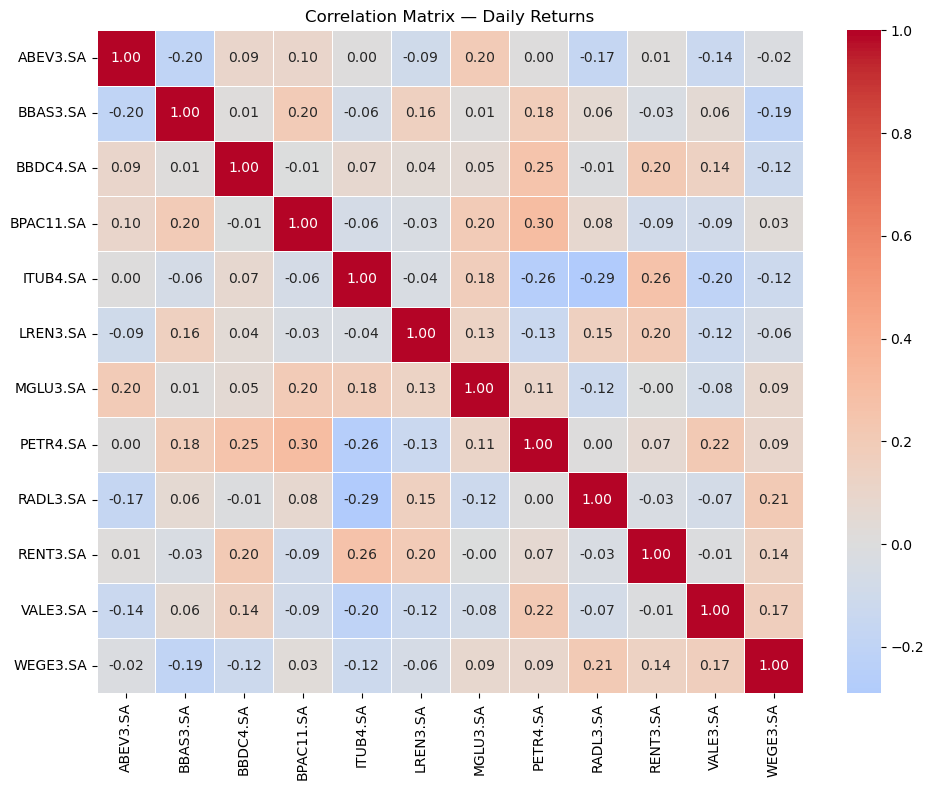

In [3]:
# Pivot to wide format: ticker → column, trade_date → index, value = daily_return
if not daily.is_empty():
    wide = (
        daily
        .select(["ticker", "trade_date", "daily_return"])
        .pivot(values="daily_return", index="trade_date", on="ticker")
        .sort("trade_date")
        .to_pandas()
        .set_index("trade_date")
        .astype(float)
    )

    corr = wide.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.5, ax=ax)
    ax.set_title("Correlation Matrix — Daily Returns")
    plt.tight_layout()
    plt.show()

## 2. Bollinger Bands

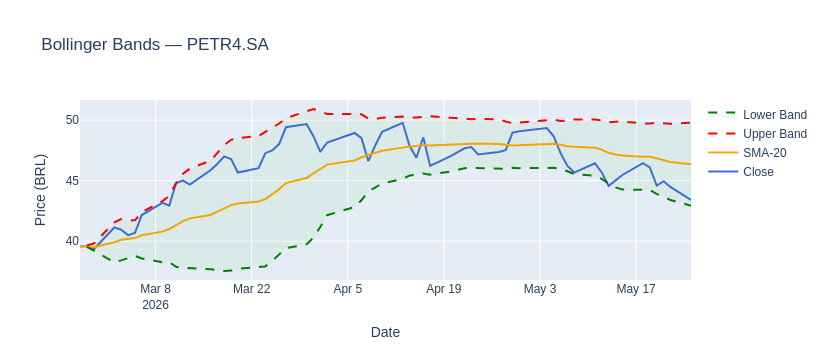

In [4]:
TICKER = "PETR4.SA"

if not daily.is_empty():
    bb = (
        daily
        .filter(pl.col("ticker") == TICKER)
        .sort("trade_date")
        .with_columns([
            pl.col("close_price").rolling_mean(window_size=20, min_samples=1).alias("sma_20"),
            pl.col("close_price").rolling_std(window_size=20, min_samples=2).alias("std_20"),
        ])
        .with_columns([
            (pl.col("sma_20") + 2 * pl.col("std_20")).alias("upper_band"),
            (pl.col("sma_20") - 2 * pl.col("std_20")).alias("lower_band"),
        ])
        .to_pandas()
    )

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=bb["trade_date"], y=bb["close_price"], name="Close", line=dict(color="royalblue")))
    fig.add_trace(go.Scatter(x=bb["trade_date"], y=bb["sma_20"],     name="SMA-20", line=dict(color="orange")))
    fig.add_trace(go.Scatter(x=bb["trade_date"], y=bb["upper_band"], name="Upper Band", line=dict(color="red", dash="dash")))
    fig.add_trace(go.Scatter(x=bb["trade_date"], y=bb["lower_band"], name="Lower Band", line=dict(color="green", dash="dash"),
                             fill="tonexty", fillcolor="rgba(0,200,0,0.05)"))
    fig.update_layout(title=f"Bollinger Bands — {TICKER}", xaxis_title="Date", yaxis_title="Price (BRL)")
    fig.show()

## 3. Equal-Weight Portfolio Back-test

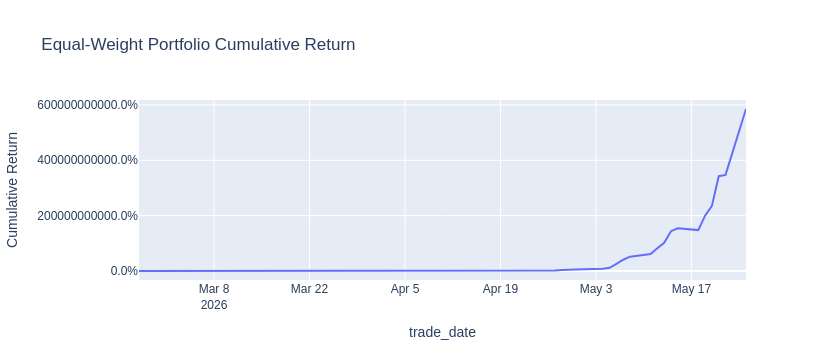

Final portfolio return: 585134110846.61%


In [5]:
if not daily.is_empty():
    portfolio = (
        daily
        .group_by("trade_date")
        .agg(pl.col("daily_return").mean().alias("portfolio_return"))
        .sort("trade_date")
        .with_columns(
            ((1 + pl.col("portfolio_return").fill_null(0)).cum_prod() - 1).alias("portfolio_cum_return")
        )
        .to_pandas()
    )

    fig = px.line(
        portfolio,
        x="trade_date",
        y="portfolio_cum_return",
        title="Equal-Weight Portfolio Cumulative Return",
        labels={"portfolio_cum_return": "Cumulative Return"},
    )
    fig.update_yaxes(tickformat=".1%")
    fig.show()

    final_return = portfolio["portfolio_cum_return"].iloc[-1]
    print(f"Final portfolio return: {final_return:.2%}")

## 4. Volume Anomaly Detection (Z-Score)

In [6]:
if not daily.is_empty():
    anomalies = (
        daily
        .with_columns([
            pl.col("volume").rolling_mean(window_size=20, min_samples=5).over("ticker").alias("vol_mean"),
            pl.col("volume").rolling_std(window_size=20, min_samples=5).over("ticker").alias("vol_std"),
        ])
        .with_columns(
            ((pl.col("volume") - pl.col("vol_mean")) / pl.col("vol_std")).alias("vol_zscore")
        )
        .filter(pl.col("vol_zscore").abs() > 3)
        .select(["ticker", "trade_date", "volume", "vol_mean", "vol_zscore"])
        .sort("vol_zscore", descending=True)
    )

    print(f"Volume anomalies detected (|z| > 3): {len(anomalies)}")
    anomalies.head(20)

Volume anomalies detected (|z| > 3): 5


## 5. PySpark — Spark SQL on Gold Data

In [7]:
from configs.spark_config import create_spark_session

spark = create_spark_session("b3-exploration")
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")

Spark version: 3.5.0


In [8]:
import os
from pathlib import Path
from configs.settings import DATA_PATH_GOLD

gold_parquet_path = str(DATA_PATH_GOLD / "daily_metrics")

if Path(gold_parquet_path).exists():
    from pyspark.sql import functions as F

    sdf = spark.read.parquet(gold_parquet_path)
    sdf.createOrReplaceTempView("gold_daily")

    result = spark.sql("""
        SELECT
            ticker,
            COUNT(*)                            AS trading_days,
            ROUND(AVG(close_price), 2)          AS avg_close,
            ROUND(AVG(volatility_20d) * 100, 2) AS avg_vol_pct,
            ROUND(MAX(cum_return) * 100, 2)     AS max_cum_return_pct
        FROM gold_daily
        GROUP BY ticker
        ORDER BY avg_vol_pct DESC
    """)
    result.show(20, truncate=False)
else:
    print("Gold Parquet not found — run GoldPipeline first (notebook 03)")

+---------+------------+---------+-----------+----------------------+
|ticker   |trading_days|avg_close|avg_vol_pct|max_cum_return_pct    |
+---------+------------+---------+-----------+----------------------+
|VALE3.SA |61          |82.68    |4409.06    |3.36861548613984E26   |
|WEGE3.SA |61          |47.07    |2514.05    |1.41187959356630208E17|
|BPAC11.SA|61          |58.07    |2388.55    |1.5614130912475356E16 |
|PETR4.SA |61          |45.99    |2173.11    |6.0161213029947E11    |
|RENT3.SA |61          |47.04    |2111.09    |3.7234633014604584E16 |
|ITUB4.SA |61          |43.17    |1951.35    |1.0032199823761951E15 |
|RADL3.SA |61          |22.49    |1237.68    |23106.08              |
|BBAS3.SA |61          |23.38    |991.64     |175.08                |
|LREN3.SA |61          |14.81    |795.24     |-14.56                |
|BBDC4.SA |61          |19.34    |783.63     |-46.31                |
|ABEV3.SA |61          |15.47    |558.65     |-65.71                |
|MGLU3.SA |61       

In [9]:
spark.stop()
print("SparkSession stopped")

SparkSession stopped
